# Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

## OPTIONAL
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

# import 

In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve
from sklearn.model_selection import KFold, cross_val_score
# from astroML.linear_model import PolinomialRegression
#non posso poiché non ho PyMC3 e se provo ad installarlo dà problemi
#uso PolynomialFeatures di sklearn


# code

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1133/4129113698.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


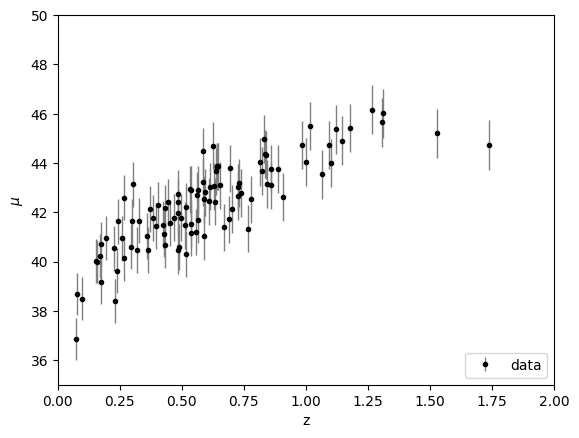

In [2]:

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

39.48384602295729 [4.76438865]


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1133/2588478566.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

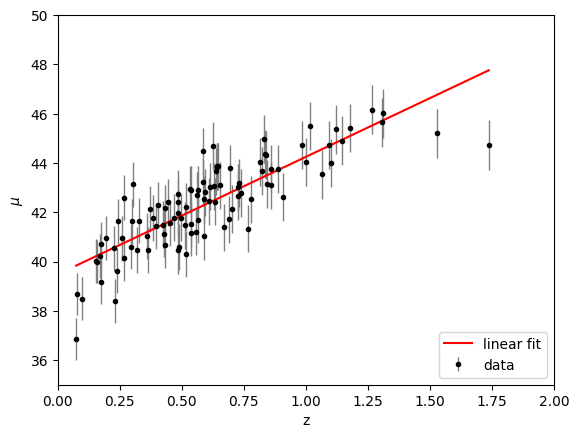

In [3]:
# trying with linear regression
weights = 1/dmu**2
lin_reg = LinearRegression()

lin_reg.fit(z_sample.reshape(-1, 1), mu_sample, sample_weight=weights)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
z_line = np.linspace(z_sample.min(), z_sample.max(), 200)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_line, lin_reg.predict(z_line.reshape(-1, 1)), '-', color='red', label='linear fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0, 2)
plt.ylim(35, 50)

In [4]:
print(dmu)

[0.91862497 0.95818624 0.94340343 0.97222794 0.97171179 0.92819662
 0.92860378 0.97385018 0.9966678  0.98218018 0.93649091 0.948558
 0.96318467 0.9656542  0.93760835 0.95334492 0.94872528 0.86485225
 0.97103496 0.98306194 0.93712847 0.95764923 0.89710554 0.93748105
 0.99104229 0.96054687 0.93997207 0.97255426 0.93265984 0.95389152
 0.98131431 0.94327408 0.97387777 0.91153822 0.96493354 0.96496076
 0.92210777 0.98951197 0.94376982 0.98691576 0.89231065 0.91764268
 0.88762944 0.96247275 0.95599473 0.95113453 0.88588283 0.95336368
 0.93388642 0.94871596 0.90572161 0.95699473 0.95372094 0.85295833
 0.95781273 0.98736141 0.97272887 1.01211963 0.99684655 0.97286954
 0.92951505 0.95841129 0.94671347 0.91917738 0.93867591 0.89019692
 0.94455508 1.00520951 0.9080577  0.90719541 0.96790571 0.95541351
 0.94618927 0.90474131 0.92335956 0.98549227 0.94164366 0.95133629
 0.85158066 0.93107145 0.943334   0.95738992 0.98835882 0.95847705
 0.96508125 0.91252869 0.96857855 0.97688395 0.95911907 0.943451

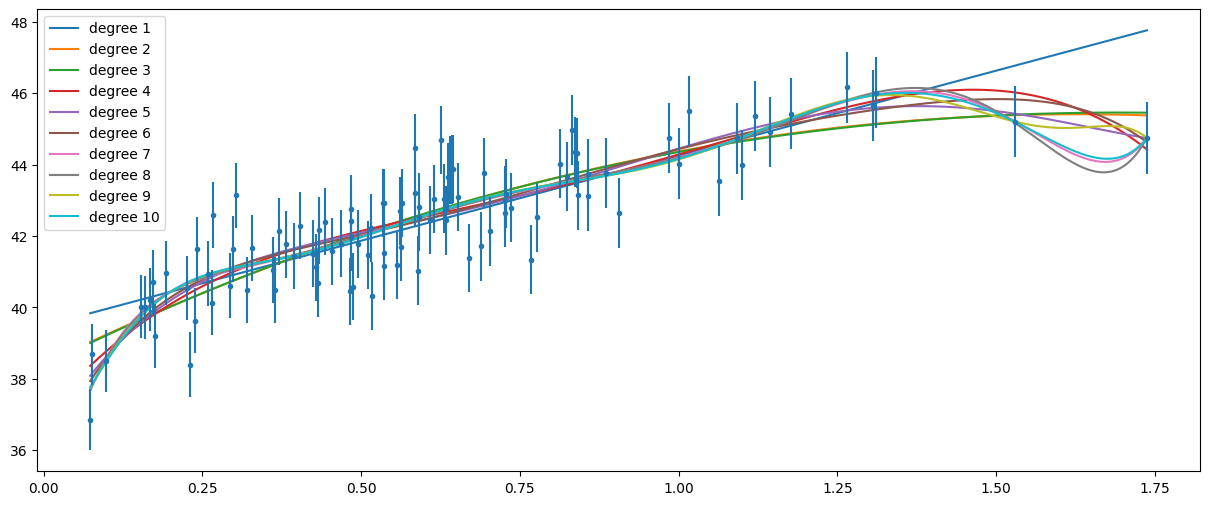

In [5]:
z_line = np.linspace(z_sample.min(), z_sample.max(), 600)
plt.figure(figsize= (15, 6))
for i in range (10):
    poli = PolynomialFeatures(degree= i+1)
    z_poli = poli.fit_transform(z_sample.reshape(-1, 1))
    lin_reg = LinearRegression()
    lin_reg.fit(z_poli, mu_sample, weights)
    theta0 = lin_reg.intercept_
    z_line_poly = poli.transform(z_line.reshape(-1, 1))
    plt.plot(z_line, lin_reg.predict(z_line_poly), '-', label=f'degree {i+1}')
plt.errorbar(z_sample, mu_sample, dmu, fmt = '.')
plt.legend()

(30.0, 60.0)

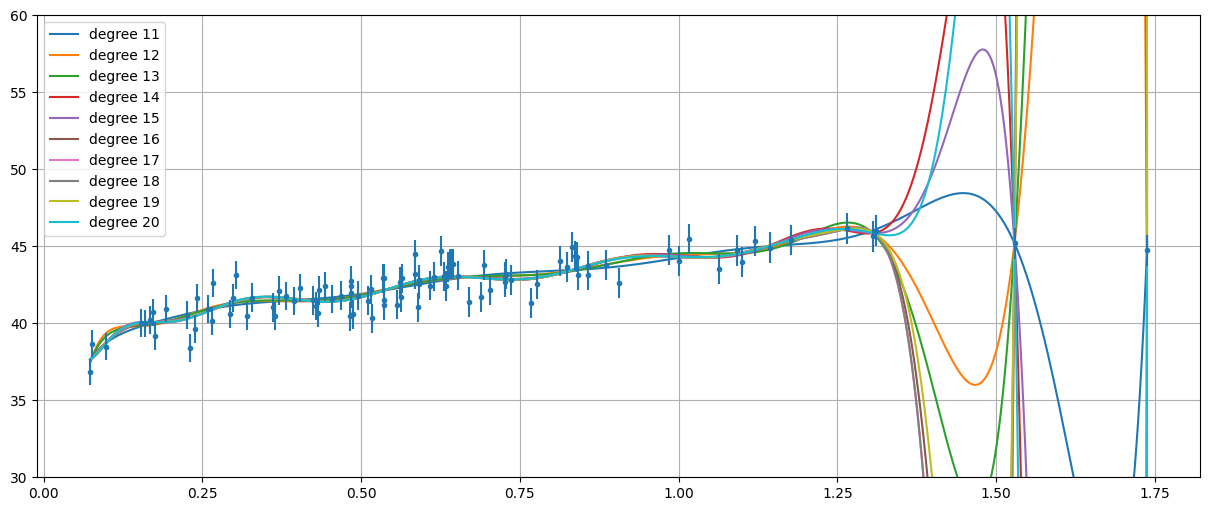

In [6]:
z_line = np.linspace(z_sample.min(), z_sample.max(), 600)
plt.figure(figsize= (15, 6))
for i in range (10):
    poli = PolynomialFeatures(degree= i+11)
    z_poli = poli.fit_transform(z_sample.reshape(-1, 1))
    lin_reg = LinearRegression()
    lin_reg.fit(z_poli, mu_sample, weights)
    theta0 = lin_reg.intercept_
    z_line_poly = poli.transform(z_line.reshape(-1, 1))
    plt.plot(z_line, lin_reg.predict(z_line_poly), '-', label=f'degree {i+11}')
plt.errorbar(z_sample, mu_sample, dmu, fmt = '.')
plt.legend()
plt.grid()
plt.ylim(30,60)

i think it is a poli of degree ~ 5

In [7]:
## now split the data in 60 % training, 20% test, 20% validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from astroML.linear_model import PolynomialRegression


z_test, z_temp, mu_test, mu_temp, dmu_test, dmu_temp = train_test_split(z_sample, mu_sample, dmu, train_size=0.20, )


/home/matti/uni/lab/myenv/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [8]:

kfold = KFold(n_splits = 4, shuffle=True)
model = PolynomialRegression(4)
scores = cross_val_score(model, z_temp.reshape(-1, 1), mu_temp, cv = kfold, scoring = 'neg_mean_squared_error')

print(scores)

#i have to do a manual loop to try different models

[-0.74385608 -0.58246376 -0.50990792 -1.47780893]


In [9]:
z_temp = z_temp.reshape(-1, 1)
z_test = z_test.reshape(-1, 1)

In [10]:

cv_scores = []
test_scores = []
models = [PolynomialRegression(3), PolynomialRegression(5), PolynomialRegression(10), PolynomialRegression(17)]
for model in models:
    for (train_index, test_index) in (kfold.split(z_temp)):
        z_train, z_cv_test = z_temp[train_index], z_temp[test_index]
        mu_train, mu_cv_test = mu_temp[train_index], mu_temp[test_index]
        model.fit(z_train, mu_train)
        mu_cv_predicted = model.predict(z_cv_test)
        mu_test_predicted = model.predict(z_test)
        cv_score = mean_squared_error(mu_cv_test, mu_cv_predicted)
        test_score = mean_squared_error(mu_test, mu_test_predicted)
        cv_scores.append(cv_score)
        test_scores.append(test_score)
    avg_cv = np.mean(cv_scores)
    avg_test = np.mean(test_scores)
    #the result is the mean of the k-fold for each model
    print(f"Model: {type(model).__name__}({model.degree}) | Avg cv MSE: {avg_cv:.4f} | Avg test MSE: {avg_test:.4f}")


Model: PolynomialRegression(3) | Avg cv MSE: 0.9279 | Avg test MSE: 1.0904
Model: PolynomialRegression(5) | Avg cv MSE: 0.8648 | Avg test MSE: 1.0841
Model: PolynomialRegression(10) | Avg cv MSE: 10.5087 | Avg test MSE: 1.0988
Model: PolynomialRegression(17) | Avg cv MSE: 44250948291890.2812 | Avg test MSE: 1.5521


the less is better, but degree 3 and degree 5 are very similar

# Part 2 (start in class)

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

# Part 3 (for the exam)

*(I know this assignment is longer and more convoluted, but we're getting towards the end of the class and it's important to draw connections between the different things we've done)*

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z')^3+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$ (notice that $\Omega_\Lambda$ is not independent because $1 = \Omega_m + \Omega_\Lambda$)
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and MCMC and/or nested sampling. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured values of $H_0$ and $\Omega_m$. What are they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem)





In [11]:
#first I try with radial-basis function, prior should be flat

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
z_test, z_temp, mu_test, mu_temp, dmu_test, dmu_temp = train_test_split(z_sample, mu_sample, dmu, train_size=0.20 )

In [12]:
kernel = 1.0 * RBF(length_scale= 0.1, length_scale_bounds= (0.01, 100)) 
#lenght is the measure of how much distant two points have to be to influence each other
gpr = GaussianProcessRegressor(kernel = kernel, alpha = 0.01) #alpha is how i am certain of my point value
gpr.fit(z_temp.reshape(-1, 1), mu_temp)


/home/matti/uni/lab/myenv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(length_scale=0.1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.01
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glos

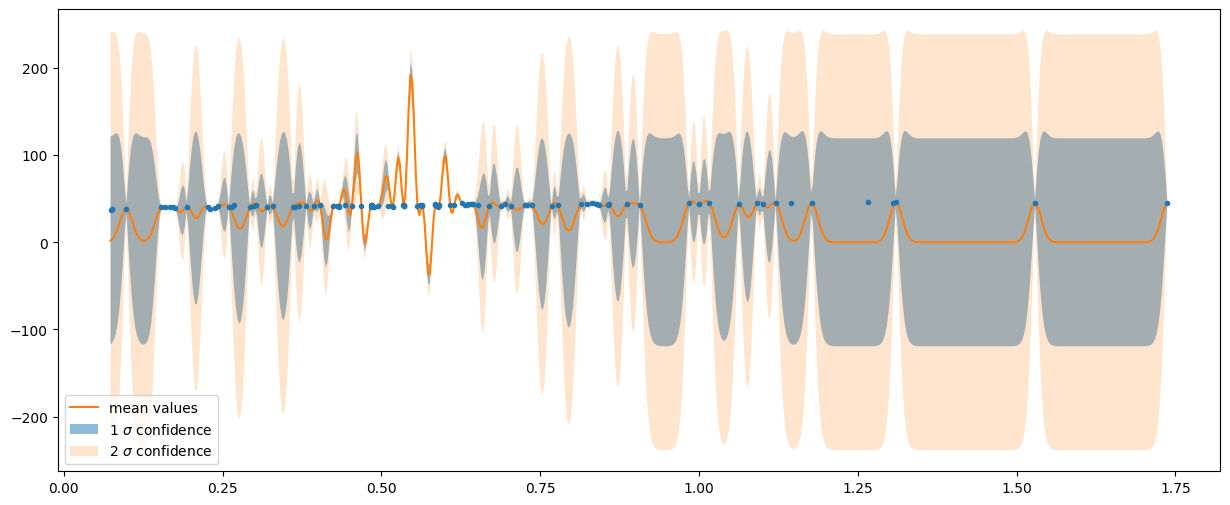

In [13]:
plt.figure(figsize = (15, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt = '.')
mu_pred, sigma_pred = gpr.predict(z_line.reshape(-1, 1), return_std = True)
y = gpr.sample_y(z_line.reshape(-1, 1))
# plt.plot(z_line, y)
plt.plot(z_line, mu_pred, label = 'mean values')
plt.fill_between(z_line, 
                  mu_pred - sigma_pred, 
                  mu_pred + sigma_pred, 
                  alpha=0.5, label=r'1 $\sigma$ confidence')
plt.fill_between(z_line, 
                  mu_pred - 2.0 * sigma_pred, 
                  mu_pred + 2.0 * sigma_pred, 
                  alpha=0.2, label=r'2 $\sigma$ confidence')
plt.legend()

sometimes it seems a very narrow width, sometimes it is too localized

alpha probably is wrong



In [14]:
print (np.mean(dmu))

0.9473481218979144


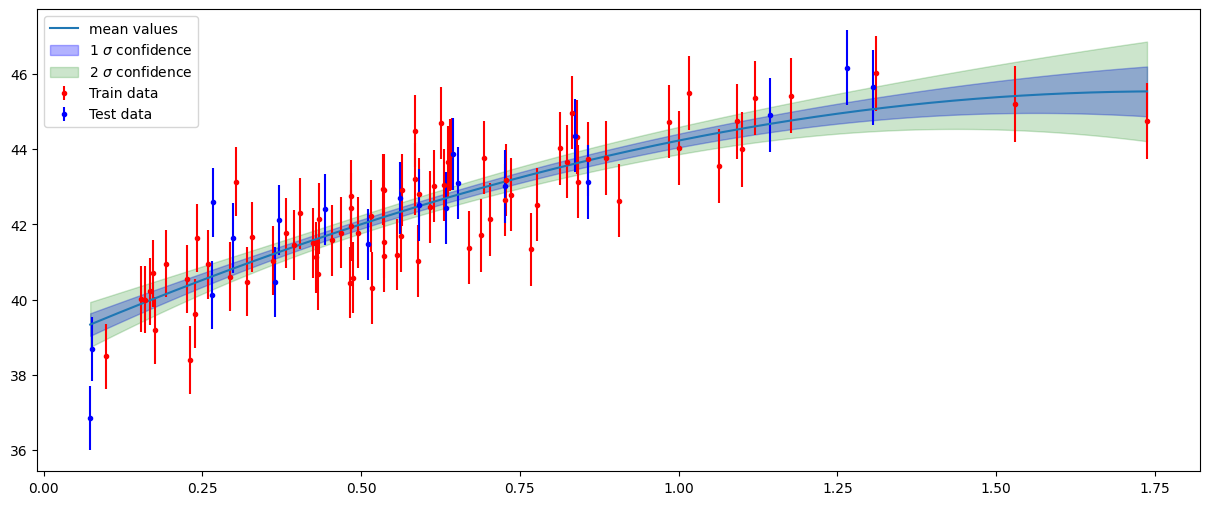

In [15]:
#try the same, but passing error as alpha
gpr = GaussianProcessRegressor(kernel = kernel, alpha = dmu_temp) 
gpr.fit(z_temp.reshape(-1, 1), mu_temp)
plt.figure(figsize = (15, 6))
plt.errorbar(z_temp, mu_temp, dmu_temp,color = 'red', fmt = '.', label = 'Train data')
plt.errorbar(z_test, mu_test, dmu_test,color = 'blue', fmt = '.', label = 'Test data')
mu_pred, sigma_pred = gpr.predict(z_line.reshape(-1, 1), return_std = True)
y = gpr.sample_y(z_line.reshape(-1, 1))
# plt.plot(z_line, y)
plt.plot(z_line, mu_pred, label = 'mean values')
plt.fill_between(z_line, 
                  mu_pred - sigma_pred, 
                  mu_pred + sigma_pred, 
                  alpha=0.3, label=r'1 $\sigma$ confidence', color = 'blue')
plt.fill_between(z_line, 
                  mu_pred - 2.0*sigma_pred, 
                  mu_pred + 2.0*sigma_pred, 
                  alpha=0.2, label=r'2 $\sigma$ confidence', color = 'green')
plt.legend()

In [16]:
#now let's see if the test data coincide with perdicted
mu_test_predicted = gpr.predict(z_test.reshape(-1, 1))
# for i in range (len(z_test)): print(mu_test[i] - mu_test_predicted[i])
test_score = mean_squared_error(mu_test, mu_test_predicted)
print (test_score)


0.8907043731919071


In [ ]:
#now generate some more data
#I already plot the posterior
from emcee import EnsembleSampler

def myLogPosterior(x, mu, sigma):
    return np.sum(-0.5 * (x - mu)**2 / sigma**2)



# plt.plot(x, y_new)

emcee: Exception while calling your likelihood function:
  params: [33.31942439 28.02439796]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/home/matti/uni/lab/myenv/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: myLogPosterior() missing 2 required positional arguments: 'mu' and 'sigma'


TypeError: myLogPosterior() missing 2 required positional arguments: 'mu' and 'sigma'

now be serious: Cross validation with k-fold, k = 4.
the two equal alpha model differ for lenght param

In [ ]:
from sklearn.gaussian_process.kernels import Matern
kernels = [ RBF(length_scale= 0.1, length_scale_bounds= (0.01, 100)),  RBF(length_scale= 10, length_scale_bounds= (0.01, 100)),
           Matern(length_scale= 0.1, length_scale_bounds= (0.01, 100)), Matern(length_scale= 10, length_scale_bounds= (0.01, 100))]
alphas = (np.mean(dmu), 1, np.mean(dmu**2), np.mean(dmu))

kfold = KFold(n_splits = 4, shuffle=True)

for (kernel, alpha) in zip(kernels, alphas):
    cv_scores = []
    test_scores = []
    for (train_index, test_index) in (kfold.split(z_temp)):
        z_train, z_cv_test = z_temp[train_index], z_temp[test_index]
        mu_train, mu_cv_test = mu_temp[train_index], mu_temp[test_index]
        gpr = GaussianProcessRegressor(kernel = kernel, alpha = alpha)
        gpr.fit(z_train.reshape(-1, 1), mu_train)
        mu_cv_predicted = gpr.predict(z_cv_test.reshape(-1, 1))
        mu_test_predicted = gpr.predict(z_test.reshape(-1, 1))
        cv_score = mean_squared_error(mu_cv_test, mu_cv_predicted)
        test_score = mean_squared_error(mu_test, mu_test_predicted)
        cv_scores.append(cv_score)
        test_scores.append(test_score)
    avg_cv = np.mean(cv_scores)
    avg_test = np.mean(test_scores)
    #the result is the mean of the k-fold for each kernel
    print(f"Kernel: {type(kernel).__name__}(alpha ={alpha}, lenght = ({kernel.length_scale}))) | Avg cv MSE: {avg_cv:.4f} | Avg test MSE: {avg_test:.4f}")


Kernel: RBF(alpha =0.9473481218979144, lenght = (0.1))) | Avg cv MSE: 2.2289 | Avg test MSE: 3.0001
Kernel: RBF(alpha =1, lenght = (10))) | Avg cv MSE: 2.4040 | Avg test MSE: 3.1469
Kernel: Matern(alpha =0.8984692073361772, lenght = (0.1))) | Avg cv MSE: 2.1619 | Avg test MSE: 2.9491
Kernel: Matern(alpha =0.9473481218979144, lenght = (10))) | Avg cv MSE: 2.2867 | Avg test MSE: 3.0699


it seems they are all equal...

i think things will be better (i would have different results) if i had more data

In [ ]:

def cosmology_func(z, H_0, Omega_m):
    #10pc ~ 3.086 * 10**17
    log = np.log10(3/(3.086*10**9) * H_0 * (1 + z) )
    return 5 * log#funct non finita!!!